In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [6]:
df=pd.read_csv("../data/processed/tesla_feature_engineered.csv")

In [7]:
X = df.drop(['Date', 'target'], axis=1)
y=df['target']

In [8]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [14]:
X_train_scaled.to_csv(
    "../data/final/X_train.csv",
    index=False
)

In [15]:
X_test_scaled.to_csv(
    "../data/final/X_test.csv",
    index=False
)

In [16]:
y_train.to_csv(
    "../data/final/y_train.csv",
    index=False
)

In [17]:
y_test.to_csv(
    "../data/final/y_test.csv",
    index=False
)

Linear Regression


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [3]:
X_train = pd.read_csv("../data/final/X_train.csv")
X_test = pd.read_csv("../data/final/X_test.csv")

y_train = pd.read_csv("../data/final/y_train.csv")
y_test = pd.read_csv("../data/final/y_test.csv")

In [4]:
lr_model = LinearRegression()

In [5]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = lr_model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)

In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [9]:
r2 = r2_score(y_test, y_pred)

In [10]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.760817637711485
RMSE: 8.0601256108937
R2 Score: 0.9691096394985051


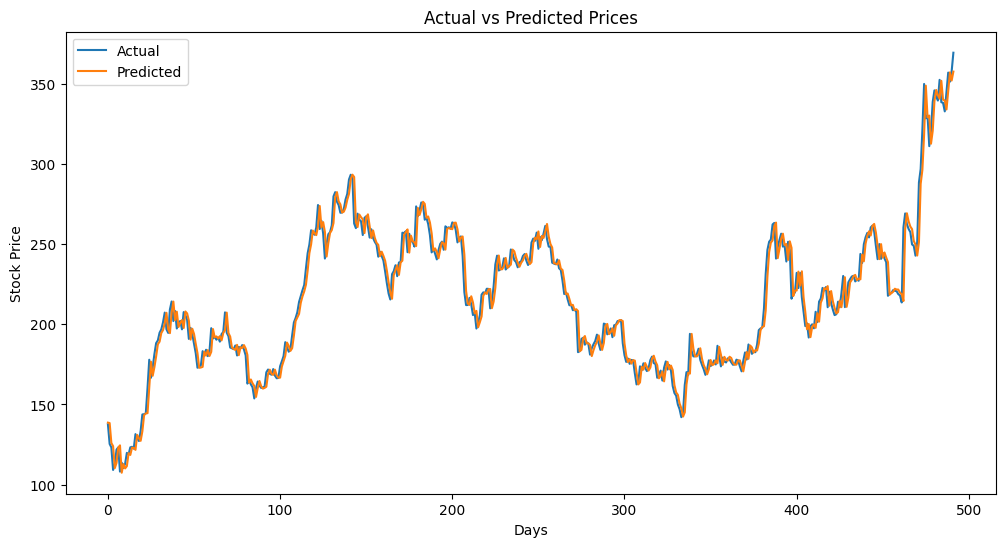

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title("Actual vs Predicted Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

Model performs quite good, with only slight variation

In [13]:
#check for overfitting
train_pred = lr_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.997449414459181
Test R2: 0.9691096394985051


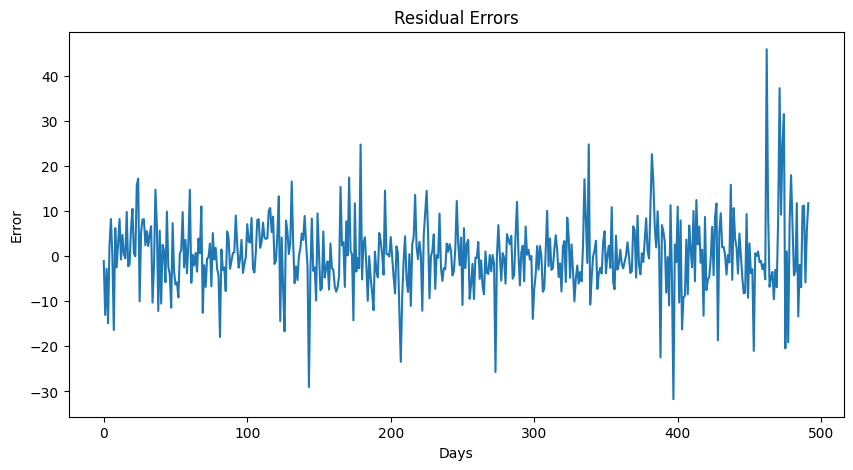

In [15]:
#Residual Analysis to check for overfitting
residuals = y_test - y_pred

plt.figure(figsize=(10,5))
plt.plot(residuals)

plt.title("Residual Errors")
plt.xlabel("Days")
plt.ylabel("Error")

plt.show()